In [3]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df = pd.read_excel(r"C:\Users\sande\OneDrive\Desktop\Telco-Customer-Churn-model\data\raw\Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [7]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [8]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [14]:
df.dtypes.value_counts()

object     24
int64       6
float64     3
Name: count, dtype: int64

In [15]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Churn Reason    5174
dtype: int64

In [21]:
(df == "").sum().sort_values(ascending=False).head(10)


CustomerID    0
Count         0
Country       0
State         0
City          0
Zip Code      0
Lat Long      0
Latitude      0
Longitude     0
Gender        0
dtype: int64

In [23]:
(df.astype(str).apply(lambda col : col.str.strip()=="")).sum().sort_values(ascending=False).head(10)

Total Charges    11
CustomerID        0
Count             0
State             0
Country           0
Zip Code          0
Lat Long          0
Latitude          0
City              0
Gender            0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['CustomerID'].duplicated().sum()

np.int64(0)

In [29]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

In [30]:
target = "Churn Label"

In [32]:
for col in df.columns:
    print(col , ":", df[col].nunique())

CustomerID : 7043
Count : 1
Country : 1
State : 1
City : 1129
Zip Code : 1652
Lat Long : 1652
Latitude : 1652
Longitude : 1651
Gender : 2
Senior Citizen : 2
Partner : 2
Dependents : 2
Tenure Months : 73
Phone Service : 2
Multiple Lines : 3
Internet Service : 3
Online Security : 3
Online Backup : 3
Device Protection : 3
Tech Support : 3
Streaming TV : 3
Streaming Movies : 3
Contract : 3
Paperless Billing : 2
Payment Method : 4
Monthly Charges : 1585
Total Charges : 6531
Churn Label : 2
Churn Value : 2
Churn Score : 85
CLTV : 3438
Churn Reason : 20


In [33]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


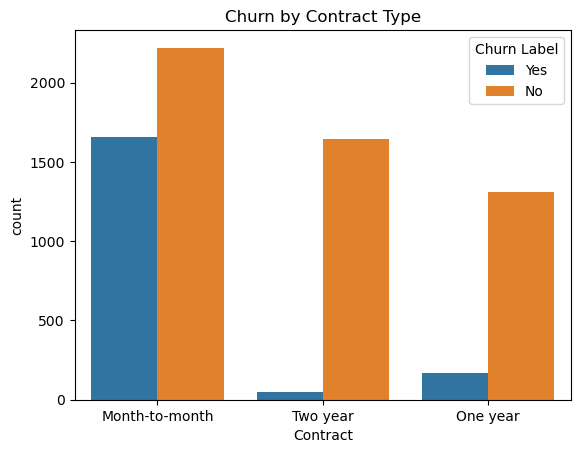

In [40]:
sns.countplot(
    data = df,
    x="Contract",
    hue="Churn Label"
)
plt.title("Churn by Contract Type")
plt.show()

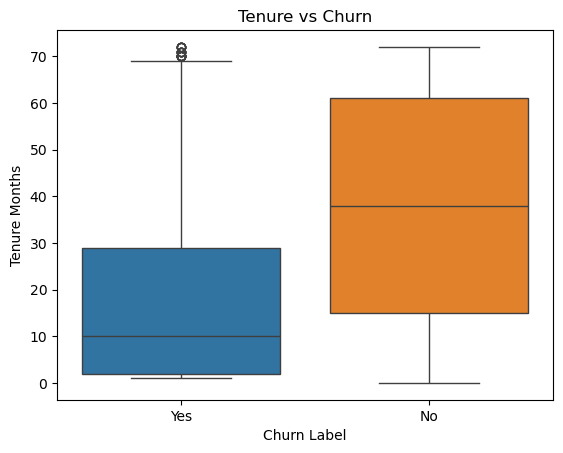

In [46]:
sns.boxplot(
    data = df,
    x="Churn Label",
    y = "Tenure Months",
    hue="Churn Label"
)
plt.title("Tenure vs Churn")
plt.show()

In [47]:
df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


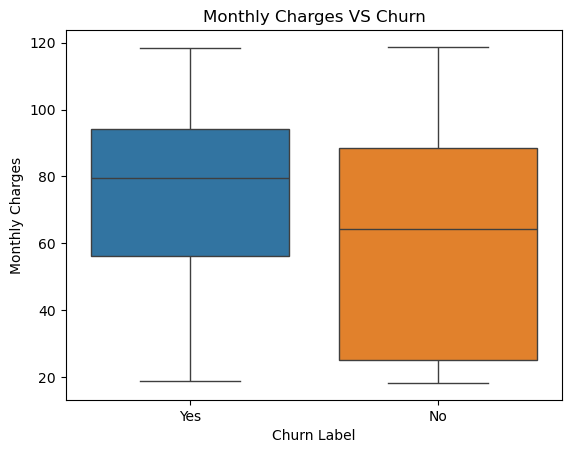

In [52]:
sns.boxplot(
    data = df,
    x="Churn Label",
    y="Monthly Charges",
    hue = "Churn Label"
)

plt.title("Monthly Charges VS Churn")
plt.show()

In [53]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [60]:
df['Total Charges']=pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)
df['Total Charges'].isnull().sum()

np.int64(11)

In [94]:
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].mean())

In [95]:
df['Tenure Months'].dtypes

dtype('int64')

In [96]:
pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize = "index"
)*100


Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


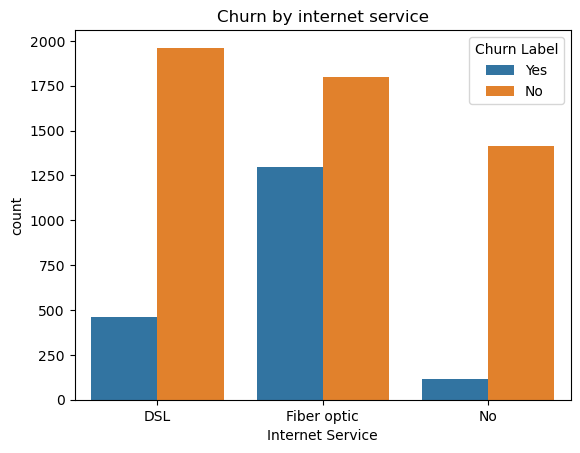

In [97]:
sns.countplot(
    data = df,
    x = "Internet Service",
    hue = "Churn Label"
)
plt.title("Churn by internet service")
plt.show()


In [98]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
)*100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


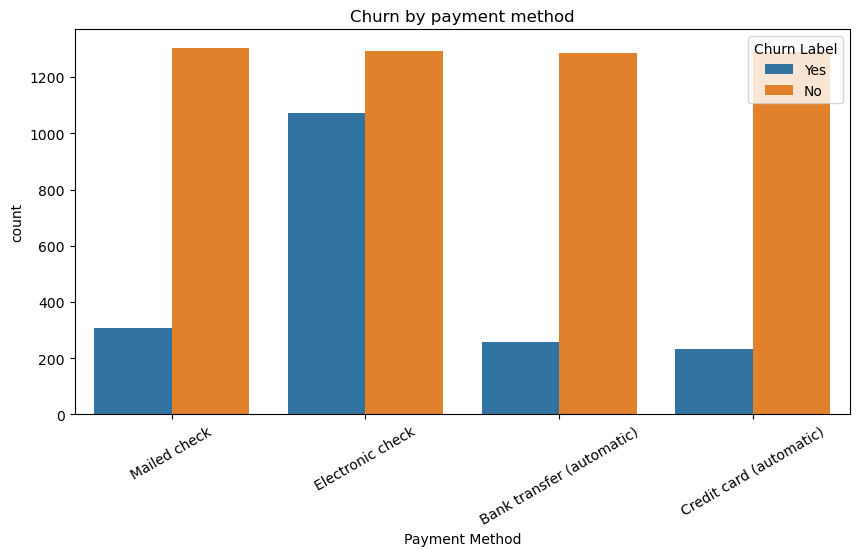

In [99]:
plt.figure(figsize=(10,5))
sns.countplot(
    data = df,
    x = "Payment Method",
    hue = "Churn Label"
)
plt.title("Churn by payment method")
plt.xticks(rotation=30)
plt.show()

In [100]:
pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize='index'
)*100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [101]:
df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]].describe()

,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441,4400.295755
std,24.559481,30.090047,2265.000258,1183.057152
min,0.000000,18.250000,18.800000,2003.000000
25%,9.000000,35.500000,402.225000,3469.000000
50%,29.000000,70.350000,1400.550000,4527.000000
75%,55.000000,89.850000,3786.600000,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


<Axes: >

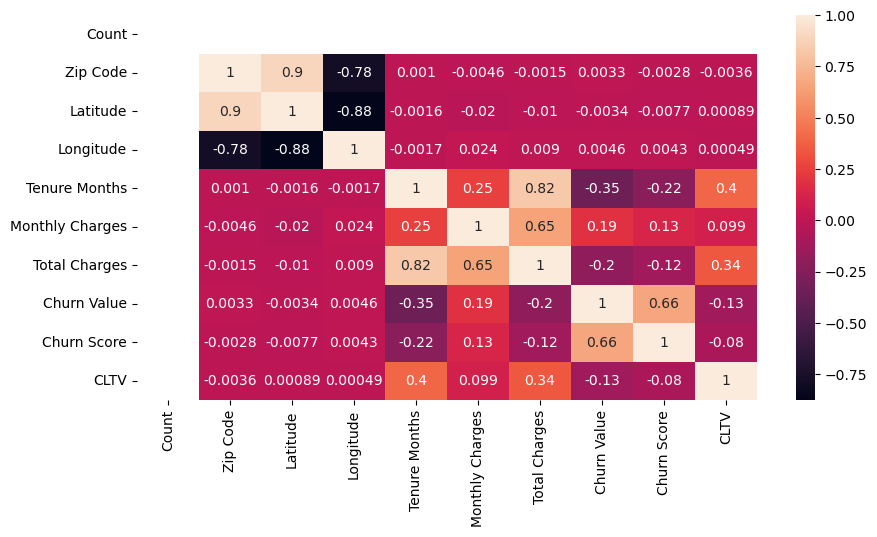

In [104]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [105]:
df[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]].corr()

,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.000000,0.247900,0.824757,0.396406,-0.352229
Monthly Charges,0.247900,1.000000,0.650468,0.098693,0.193356
Total Charges,0.824757,0.650468,1.000000,0.341384,-0.199428
CLTV,0.396406,0.098693,0.341384,1.000000,-0.127463
Churn Value,-0.352229,0.193356,-0.199428,-0.127463,1.000000
